In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [31]:
df = pd.read_csv("Telco_Customer_Churn_Dataset.csv")

sns.set_style("whitegrid")

In [32]:
def tenure_group(month):
    if month <= 12:
        return "0-12 Months"
    elif month <= 36:
        return "13-36 Months"
    else:
        return "37+ Months"

df["tenure_group"] = df["tenure"].apply(tenure_group)
print("\nAverage Statistics by Tenure Group")


Average Statistics by Tenure Group


In [33]:
print(df[["MonthlyCharges", "TotalCharges"]].dtypes)

MonthlyCharges    float64
TotalCharges       object
dtype: object


In [34]:
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [35]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

In [36]:
group_stats = df.groupby("tenure_group")[["MonthlyCharges", "TotalCharges"]].agg(
    ["mean", "median", "min", "max"]
)

In [38]:
group_stats = df.groupby("tenure_group")[["MonthlyCharges", "TotalCharges"]].agg(
    ["mean", "median", "min", "max"]
)

In [39]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group']


In [41]:

print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
tenure_group         object
dtype: object


In [43]:
print(group_stats)
print("\nChurn Rate by Tenure Group")

             MonthlyCharges                        TotalCharges            \
                       mean  median    min     max         mean    median   
tenure_group                                                                
0-12 Months       56.097781  55.900  18.75  112.95   282.261722   174.550   
13-36 Months      63.248195  69.675  18.25  116.25  1513.541756  1404.975   
37+ Months        72.008730  80.300  18.40  118.75  4213.723192  4282.400   

                                
                 min       max  
tenure_group                    
0-12 Months    18.80  1397.475  
13-36 Months  218.55  4025.500  
37+ Months    677.05  8684.800  

Churn Rate by Tenure Group


In [45]:
churn_tenure = pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
) * 100

print(churn_tenure)
plt.figure(figsize=(8,5))

Churn                No        Yes
tenure_group                      
0-12 Months   52.561757  47.438243
13-36 Months  74.461207  25.538793
37+ Months    88.070643  11.929357


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

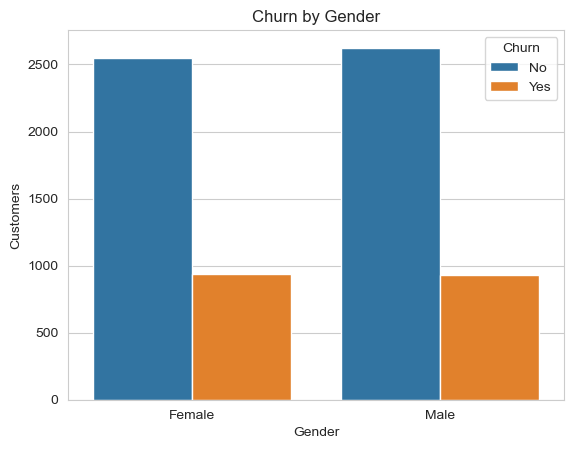

In [47]:
sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Customers")

plt.show()

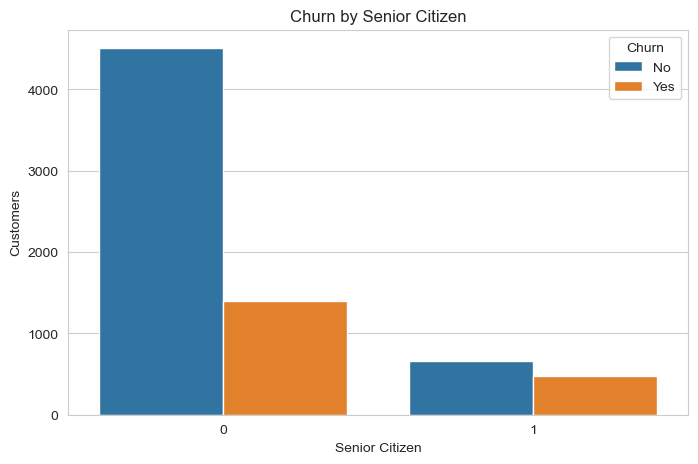

In [48]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Churn by Senior Citizen")
plt.xlabel("Senior Citizen")
plt.ylabel("Customers")

plt.show()

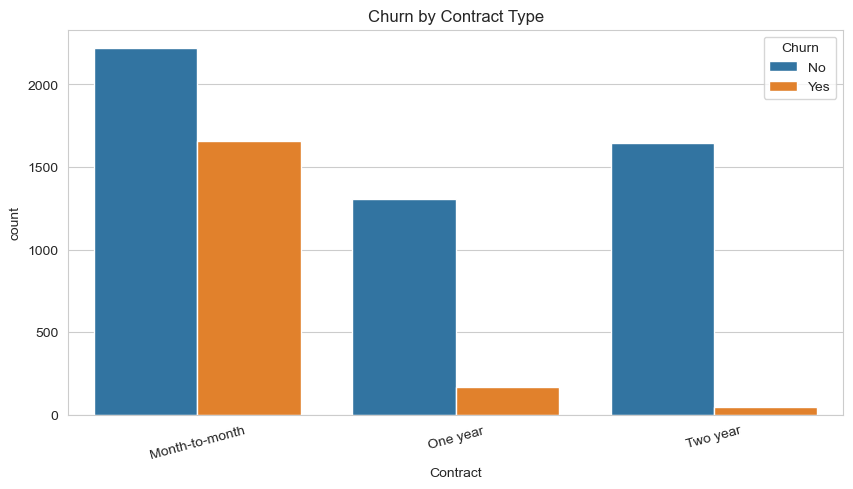

In [50]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")

plt.xticks(rotation=15)

plt.show()

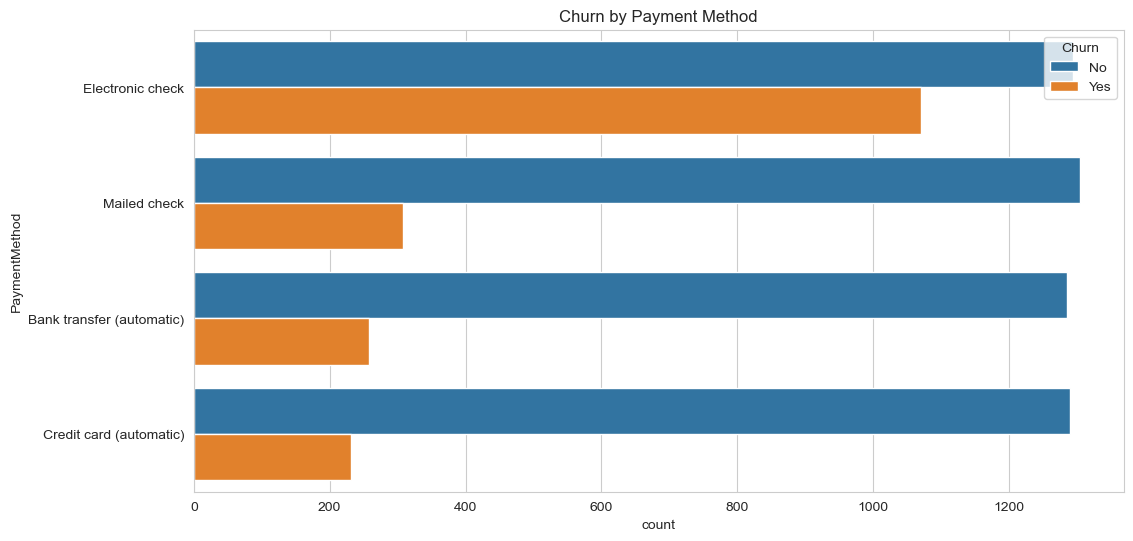

In [52]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="PaymentMethod",
    hue="Churn"
)

plt.title("Churn by Payment Method")

plt.show()

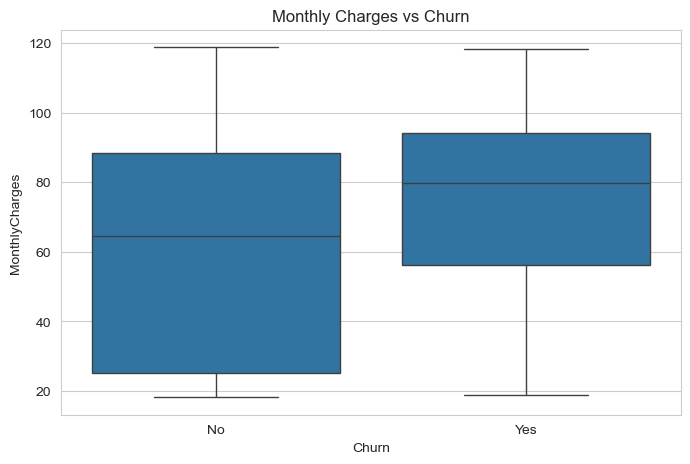

In [54]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")

plt.show()

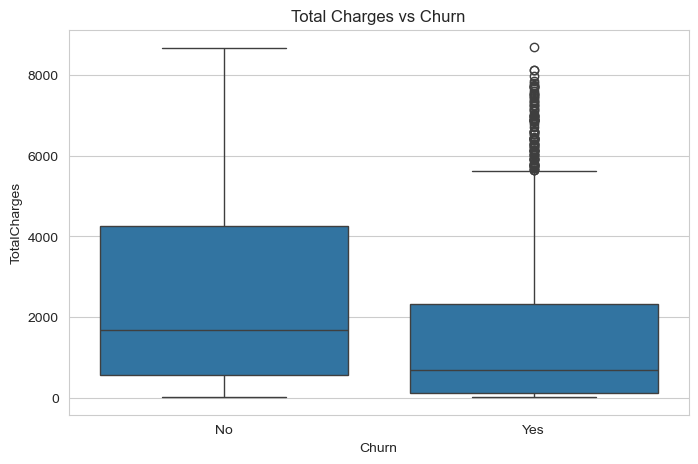

In [55]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges vs Churn")

plt.show()

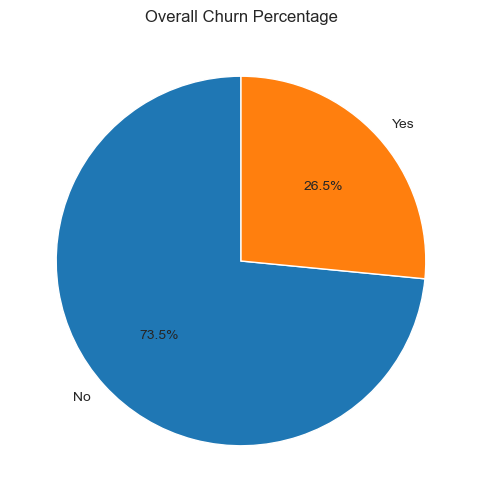

In [56]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))

plt.pie(
    churn_percentage,
    labels=churn_percentage.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Churn Percentage")

plt.show()


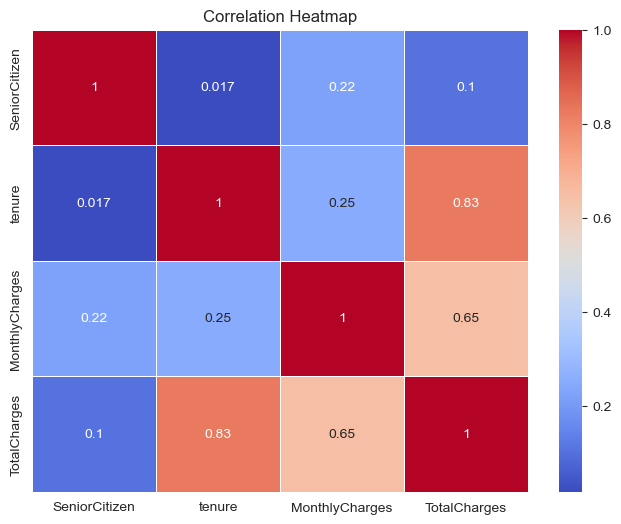

In [57]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [59]:
print("\nTop 10 Customers by Total Charges")

top_customers = df.nlargest(
    10,
    "TotalCharges"
)[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract"]]

print(top_customers)


Top 10 Customers by Total Charges
      customerID  tenure  MonthlyCharges  TotalCharges  Contract
4610  2889-FPWRM      72          117.80       8684.80  One year
4586  7569-NMZYQ      72          118.75       8672.45  Two year
6768  9739-JLPQJ      72          117.50       8670.10  Two year
5347  9788-HNGUT      72          116.95       8594.40  Two year
2187  8879-XUAHX      71          116.25       8564.75  Two year
6118  9924-JPRMC      72          118.20       8547.15  Two year
5558  0675-NCDYU      72          116.40       8543.25  Two year
2368  6650-BWFRT      72          117.15       8529.50  Two year
2603  0164-APGRB      72          114.90       8496.70  Two year
2025  1488-PBLJN      72          116.85       8477.70  Two year


In [60]:
print("\n" + "-" * 60)
print("BUSINESS INSIGHTS")
print("-" * 60)

print("""
1. Customers on Month-to-Month contracts show higher churn.

2. Customers with shorter tenure (0-12 months) are more likely to leave.

3. Customers paying higher monthly charges tend to churn more.

4. Long-term customers generate higher total revenue.

5. Electronic Check payment method has comparatively higher churn.

6. Senior citizens have a relatively higher churn rate.

7. Long-term contracts improve customer retention.

8. Customer loyalty programs can reduce churn among new customers.
""")

print("-" * 60)
print("ADVANCED ANALYSIS COMPLETED SUCCESSFULLY")
print("-" * 60)


------------------------------------------------------------
BUSINESS INSIGHTS
------------------------------------------------------------

1. Customers on Month-to-Month contracts show higher churn.

2. Customers with shorter tenure (0-12 months) are more likely to leave.

3. Customers paying higher monthly charges tend to churn more.

4. Long-term customers generate higher total revenue.

5. Electronic Check payment method has comparatively higher churn.

6. Senior citizens have a relatively higher churn rate.

7. Long-term contracts improve customer retention.

8. Customer loyalty programs can reduce churn among new customers.

------------------------------------------------------------
ADVANCED ANALYSIS COMPLETED SUCCESSFULLY
------------------------------------------------------------
